In [160]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['NanumGothic']


In [161]:
df = pd.read_csv('21_cmapss_fd001_sample.csv')
print(df.shape)

(1031, 10)


## 실습 1. 센서 시계열 그려보기
한 엔진의 센서 값을 회차 순서대로 선 그래프로 보기

목표
- 한 엔진의 센서 값을 회차 순서대로 선 그래프로 그려 변화 방향 읽기

단계
- 2번 엔진을 골라 회차를 가로축으로 준비
- 센서 하나를 선 그래프로 그리기
- 제목·축 이름을 붙이고 값이 오르내리는 방향 읽기

예상 결과
- 회차가 늘수록 값이 서서히 오르는 곡선

(287, 10)
192    1399.71
193    1400.55
194    1398.30
195    1401.12
196    1399.49
Name: s_4, dtype: float64


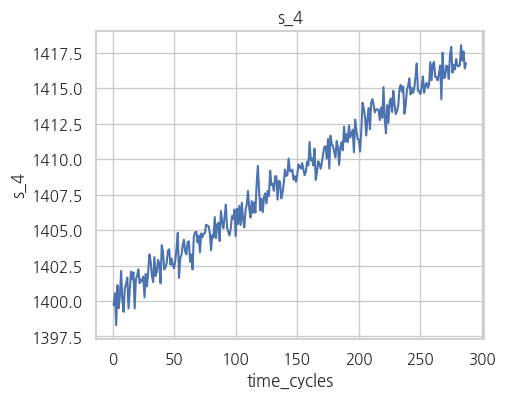

In [162]:
engine2 = df[df['unit_nr'] == 2]
print(engine2.shape)
print(engine2['s_4'].head())

plt.figure(figsize=(5,4))
plt.title('s_4')
plt.plot(engine2['time_cycles'], engine2['s_4'])
plt.xlabel('time_cycles')
plt.ylabel('s_4')
plt.show()

## 실습 2. 이동평균선으로 추세 보기
떨리는 원본 위에 매끈한 이동평균선을 겹쳐 추세 보기

목표
- 떨리는 원본 위에 매끈한 이동평균선을 겹쳐 추세를 드러내기

단계
- 창 크기 10으로 이동평균을 구하기
- 원본과 이동평균을 한 그래프에 겹쳐 그리기
- 범례를 붙이고 이동평균이 추세를 드러냄을 확인

예상 결과
- 들쭉날쭉한 원본 사이로 매끈한 상승 추세선

474    1416.927
475    1416.890
476    1416.857
477    1416.887
478    1416.898
Name: s_4, dtype: float64
9


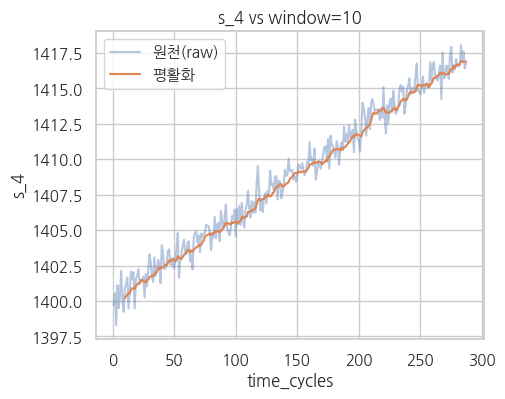

In [163]:
move10 = engine2['s_4'].rolling(window=10).mean()
print(move10.tail())
print(move10.isna().sum().sum())

plt.figure(figsize=(5,4))
plt.title('s_4 vs window=10')
plt.plot(engine2['time_cycles'], engine2['s_4'], label='원천(raw)', alpha=0.4)
plt.plot(engine2['time_cycles'], move10, label='평활화',)
plt.legend()
plt.xlabel('time_cycles')
plt.ylabel('s_4')
plt.show()

## 실습 3. 윈도우 크기 바꿔 비교하기
창 크기를 바꿔 매끈함과 빈 구간의 맞교환 관찰

목표
- 창 크기를 5·20·50으로 바꿔 매끈함과 빈 구간의 맞교환을 관찰

단계
- 원본을 옅게 그린 뒤 세 가지 창 크기 이동평균을 겹치기
- 창이 클수록 더 매끄럽지만 앞쪽 빈 구간이 긺을 확인
- 범례로 어느 선이 어느 창인지 구분

예상 결과
- 창이 클수록 매끈하지만 시작 부분 빈 구간이 늘어남

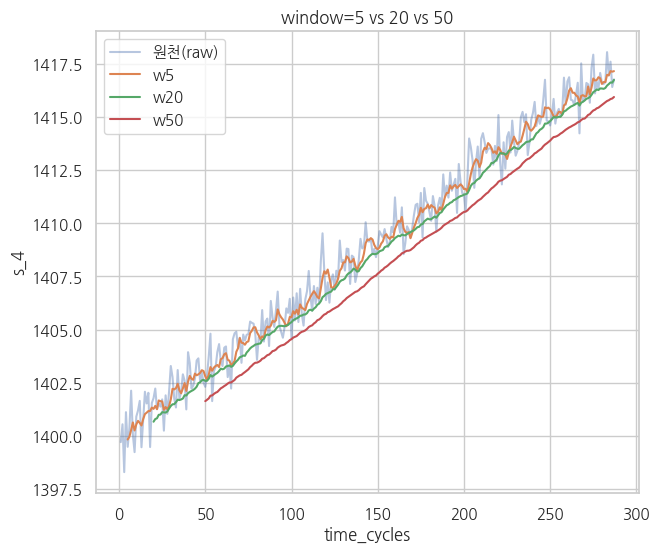

In [164]:
move5 = engine2['s_4'].rolling(window=5).mean()
move20 = engine2['s_4'].rolling(window=20).mean()
move50 = engine2['s_4'].rolling(window=50).mean()

plt.figure(figsize=(7,6))
plt.title('window=5 vs 20 vs 50')
plt.plot(engine2['time_cycles'], engine2['s_4'], label='원천(raw)', alpha=0.4)
plt.plot(engine2['time_cycles'], move5, label='w5',)
plt.plot(engine2['time_cycles'], move20, label='w20',)
plt.plot(engine2['time_cycles'], move50, label='w50',)
plt.legend()
plt.xlabel('time_cycles')
plt.ylabel('s_4')
plt.show()

## 실습 4. 여러 센서 추세 방향 비교
여러 센서의 이동평균을 함께 그려 방향 비교

목표
- 여러 센서의 이동평균을 함께 그려 상승·하강 방향을 비교

단계
- 대상 센서마다 창 크기 20 이동평균을 구하기
- 한 그래프에 겹쳐 그리고 범례를 붙이기
- 각 센서가 오르는지 내리는지 방향 판정

예상 결과
- 어떤 센서는 상승, 어떤 센서는 하강하는 서로 다른 방향

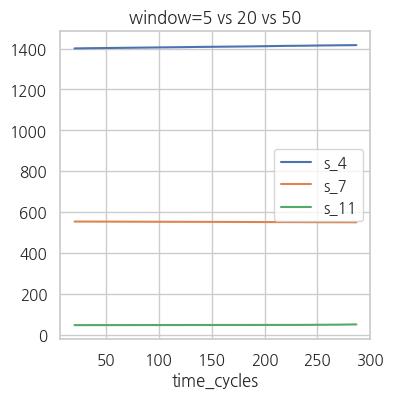

In [165]:
sensors = ['s_4', 's_7', 's_11']

plt.figure(figsize=(4,4))
plt.title('window=5 vs 20 vs 50')

for sensor in sensors:
  move20 = engine2[sensor].rolling(window=20).mean()
  plt.plot(engine2['time_cycles'], move20, label=sensor,)

plt.legend()
plt.xlabel('time_cycles')
plt.show()


## 실습 5. 이동표준편차로 변동성 구간 찾기
원본과 이동표준편차를 위아래로 나눠 그려 구간 찾기

목표
- 원본과 이동표준편차를 위아래로 나눠 그려 흔들림이 큰 구간을 찾기

단계
- 창 크기 20으로 이동표준편차를 구하기
- 위칸에 원본, 아래칸에 이동표준편차를 그리기
- 표준편차가 치솟는 구간을 변동성이 큰 구간으로 표시

예상 결과
- 후반부에서 이동표준편차가 커지는 불안정 구간

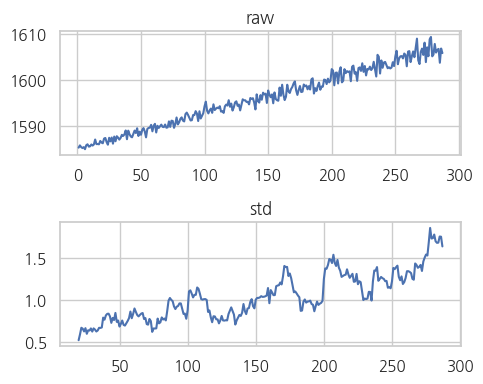

In [170]:
std20 = engine2['s_3'].rolling(window=20).std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5,4))

ax1.set_title('raw')
ax1.plot(engine2['time_cycles'], engine2['s_3'])

ax2.set_title('std')
ax2.plot(engine2['time_cycles'], std20)

plt.tight_layout()
plt.show()

## 실습 6. 평균과 변동성 밴드 함께 그리기
이동평균선에 표준편차 두 배 띠를 둘러 정상 범위 보기

목표
- 이동평균선에 표준편차 두 배 띠를 둘러 정상 범위를 시각화

단계
- 창 크기 20으로 이동평균과 이동표준편차를 구하기
- 원본과 이동평균을 그리기
- 평균에 표준편차 두 배를 더하고 뺀 띠를 색으로 채우기

예상 결과
- 이동평균 주위로 폭이 변하는 정상 범위 띠

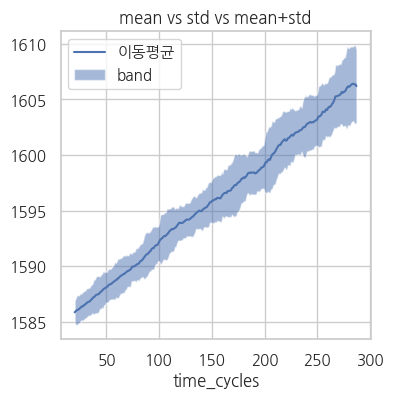

In [176]:
#이동평균
ma = engine2['s_3'].rolling(window=20).mean()

#이동표준편차
std = engine2['s_3'].rolling(window=20).std()

plt.figure(figsize=(4,4))
plt.title('mean vs std vs mean+std')

# plt.plot(engine2['time_cycles'], engine2['s_3'], label='이동평균')
plt.plot(engine2['time_cycles'], ma, label='이동평균')
# plt.plot(engine2['time_cycles'], std, label='이동표준편차')

top = ma + 2 * std
bottom = ma - 2 * std

plt.fill_between(engine2['time_cycles'], bottom, top, alpha=0.5, label='band')

plt.legend()
plt.xlabel('time_cycles')
plt.show()

## 실습 7. 변동성 패턴 해석
여러 센서의 이동표준편차로 점증·급증 패턴 비교

목표
- 여러 센서의 이동표준편차를 나눠 그려 점증·급증 패턴을 비교

단계
- 대상 센서마다 창 크기 20 이동표준편차를 구하기
- 센서별로 칸을 나눠 각각 그리기
- 서서히 커지는 점증과 갑자기 튀는 급증을 구분

예상 결과
- 센서마다 다른 변동성 패턴 — 완만한 증가와 급한 튐

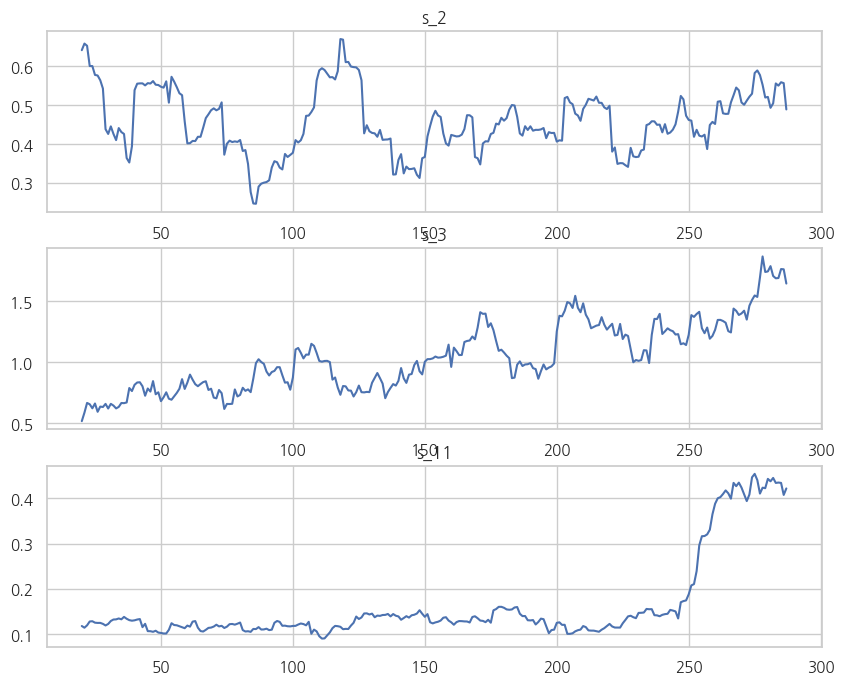

<Figure size 400x400 with 0 Axes>

In [187]:
sensors = ['s_2', 's_3', 's_11']


fig, axes = plt.subplots(3, 1, figsize=(10,8))

plt.figure(figsize=(4,4))

for ax, sensor in zip(axes, sensors):
  std20 = engine2[sensor].rolling(window=20).std()
  ax.plot(engine2['time_cycles'], std20, label=sensor)

  ax.set_title(sensor)

plt.tight_layout()
plt.show()